# Análisis Exploratorio de Datos — April Collections

**Ciencia de Datos II · Grupo 5 · Sección 77**
Kevin Zúniga · Nahún Reyes · Wilmer Sánchez

---

Este cuaderno explora el conjunto de datos que produce el ETL (`python -m etl.ejecutar`)
a partir de la base de datos de April Collections, con el objetivo de responder una
pregunta concreta:

> **¿Qué distingue a una venta fiada que se paga a tiempo de una que cae en mora?**

Lo que se encuentre aquí decide qué variables entran al modelo de riesgo crediticio
del cuaderno siguiente.

## Sobre los datos

Los datos son **sintéticos**, generados con `datos/generar.py` y semilla fija. La
aplicación lleva pocas semanas en uso real y tiene un puñado de ventas: insuficiente
para entrenar. Y aunque hubiera más, no se usarían — contienen nombres, DNI y
teléfonos de clientas reales que no consintieron aparecer en un trabajo académico.

El generador simula el comportamiento de pago; **no asigna la mora**. La etiqueta la
deriva el ETL a partir de los abonos y las fechas prometidas, igual que habría que
hacer con datos reales.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# El cuaderno se abre desde notebooks/, asi que la raiz del proyecto no esta en
# la ruta de importacion y `from etl...` fallaria.
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

FIGURAS = RAIZ / "docs" / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

# Paleta del producto, para que las figuras del documento se vean como la aplicacion.
ROSA, ROSA_OSCURO, ORO, VERDE, GRIS = "#c8697a", "#9e3f52", "#c9a96e", "#4a9e7a", "#7a6570"

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})


def guardar(nombre):
    """Guarda la figura para el documento y la muestra."""
    plt.savefig(FIGURAS / f"{nombre}.png")
    plt.show()


def lempiras(centavos):
    """Los importes viven en centavos enteros; para leerlos hacen falta lempiras."""
    return centavos / 100

In [2]:
datos = pd.read_parquet(RAIZ / "datos" / "procesados" / "dataset.parquet")

print(f"filas    {len(datos):,}")
print(f"columnas {len(datos.columns)}")
print(f"clientas {datos['cliente_id'].nunique():,}")
print(f"periodo  {datos['fecha'].min():%Y-%m-%d} a {datos['fecha'].max():%Y-%m-%d}")

datos.head()

filas    2,188
columnas 26
clientas 380
periodo  2024-10-17 a 2026-08-31


,id,cliente_id,cliente_nombre,fecha,tipo_pago,categoria_producto,total_centavos,abono_inicial_centavos,porcentaje_abono_inicial,porcentaje_ganancia,...,tasa_mora_previa,gastado_previo_centavos,dias_desde_compra_previa,mes,anio,dia_semana,estado_pago,fecha_corte,cobrado_al_corte,pendiente_al_corte
0,b'\xc6W]#\xd6\xc2F)\x8b\x05\x8a\x06\xe6Q\x13\x04',b'\x02\nD\x97t\xedAE\x8d\x97e\xc7\x16\x1d\\\x87',Olga Garcia,2026-05-28,abono,Bolsos,167000,29276,17.53,32.72,...,0.0,0,-1,5,2026,3,0,2026-06-27,167000,0
1,b'A/*\xf7\xee\xeaA\xda\xae\x87<7\x93\xb9\x8f4',b'\x02\nD\x97t\xedAE\x8d\x97e\xc7\x16\x1d\\\x87',Olga Garcia,2026-06-02,credito,Perfumes,383000,0,0.00,22.07,...,0.0,167000,5,6,2026,1,1,2026-06-23,208690,174310
2,b'\xf8\xechz\\\xa9J]\xb6\xa2\x04/s\xc8a\xf3',b'\x02\x14\x1ah\x95-Hl\x96\xdb\x8a\x18\xfd\x83...,Sandra Ramirez,2025-10-21,abono,Maquillaje,69000,13938,20.20,26.70,...,0.0,0,-1,10,2025,1,1,2025-11-11,41469,27531
3,b'f\xf0\xbb8\x06\xdfOj\xb2|=\xeb2Q\x91\x8c',b'\x02\x14\x1ah\x95-Hl\x96\xdb\x8a\x18\xfd\x83...,Sandra Ramirez,2025-12-10,credito,Perfumes,68000,45333,66.67,22.74,...,1.0,69000,50,12,2025,2,0,2025-12-18,68000,0
4,b'\xac\xb6\x90\xc2eYL\x86\xae\x99g\x1d[\xb2\xe...,b'\x02\x14\x1ah\x95-Hl\x96\xdb\x8a\x18\xfd\x83...,Sandra Ramirez,2025-12-15,abono,Joyeria,99000,49397,49.90,32.10,...,0.5,137000,5,12,2025,0,1,2026-01-14,52649,46351


---
## 1. Panorama general

Antes de buscar patrones hay que saber qué hay: tipos, rangos y si falta algo.

In [3]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 2188 entries, 0 to 2187
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   id                        2188 non-null   object        
 1   cliente_id                2188 non-null   object        
 2   cliente_nombre            2188 non-null   str           
 3   fecha                     2188 non-null   datetime64[ms]
 4   tipo_pago                 2188 non-null   str           
 5   categoria_producto        2188 non-null   str           
 6   total_centavos            2188 non-null   int64         
 7   abono_inicial_centavos    2188 non-null   int64         
 8   porcentaje_abono_inicial  2188 non-null   float64       
 9   porcentaje_ganancia       2188 non-null   float64       
 10  articulos                 2188 non-null   int64         
 11  lineas                    2188 non-null   int64         
 12  dias_para_pago            2188 

In [4]:
# Solo las ventas FIADAS entran al analisis: al contado se paga en el acto y no
# puede haber mora. El ETL ya las dejo fuera.
resumen = datos[[
    "total_centavos", "abono_inicial_centavos", "porcentaje_abono_inicial",
    "porcentaje_ganancia", "dias_para_pago", "articulos",
    "historial_mora", "compras_previas",
]].describe().T

resumen["media"] = resumen["mean"].round(2)
resumen[["count", "media", "std", "min", "50%", "max"]].round(2)

,count,media,std,min,50%,max
total_centavos,2188.0,149038.85,114665.31,8000.00,115000.00,740000.00
abono_inicial_centavos,2188.0,41771.36,59650.78,0.00,20251.50,559408.00
porcentaje_abono_inicial,2188.0,27.62,26.18,0.00,26.86,89.99
porcentaje_ganancia,2188.0,26.45,4.25,17.61,26.55,37.78
dias_para_pago,2188.0,22.53,8.18,8.00,30.00,30.00
articulos,2188.0,2.19,1.33,1.00,2.00,8.00
historial_mora,2188.0,0.86,1.31,0.00,0.00,10.00
compras_previas,2188.0,3.60,3.34,0.00,3.00,22.00


In [5]:
nulos = datos.isna().sum()
print("Valores faltantes por columna:")
print(nulos[nulos > 0] if nulos.any() else "  ninguno")

Valores faltantes por columna:
  ninguno


**No hay valores faltantes.** No es casualidad ni suerte: el ETL los resuelve en origen.
Las clientas sin DNI o sin teléfono existen —son campos opcionales en la aplicación— pero
esas columnas no entran al análisis, porque un documento de identidad no dice nada sobre
si alguien va a pagar.

---
## 2. Análisis univariado

Cómo se distribuye cada variable por separado.

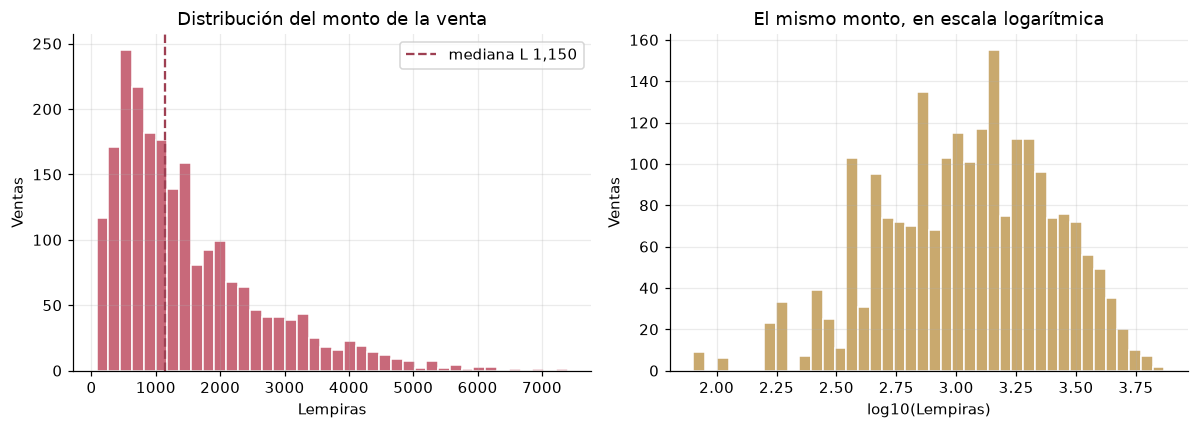

media    L   1,490.39
mediana  L   1,150.00
maximo   L   7,400.00


In [6]:
fig, (izq, der) = plt.subplots(1, 2, figsize=(11, 4))

montos = lempiras(datos["total_centavos"])
izq.hist(montos, bins=40, color=ROSA, edgecolor="white")
izq.axvline(montos.median(), color=ROSA_OSCURO, linestyle="--",
            label=f"mediana L {montos.median():,.0f}")
izq.set_title("Distribución del monto de la venta")
izq.set_xlabel("Lempiras")
izq.set_ylabel("Ventas")
izq.legend()

# En escala logaritmica se ve la forma real: la cola larga aplasta el histograma.
der.hist(np.log10(montos.clip(lower=1)), bins=40, color=ORO, edgecolor="white")
der.set_title("El mismo monto, en escala logarítmica")
der.set_xlabel("log10(Lempiras)")
der.set_ylabel("Ventas")

plt.tight_layout()
guardar("01_distribucion_montos")

print(f"media    L {montos.mean():>10,.2f}")
print(f"mediana  L {montos.median():>10,.2f}")
print(f"maximo   L {montos.max():>10,.2f}")

La distribución tiene **cola larga a la derecha**: muchas ventas pequeñas y unas pocas
grandes. La media queda por encima de la mediana, que es la firma de ese sesgo.

Importa para el modelo: los algoritmos lineales sufren con variables así, y puede
convenir transformarlas. Los basados en árboles —como Random Forest— no se ven afectados,
porque solo les importa el orden de los valores y no su escala.

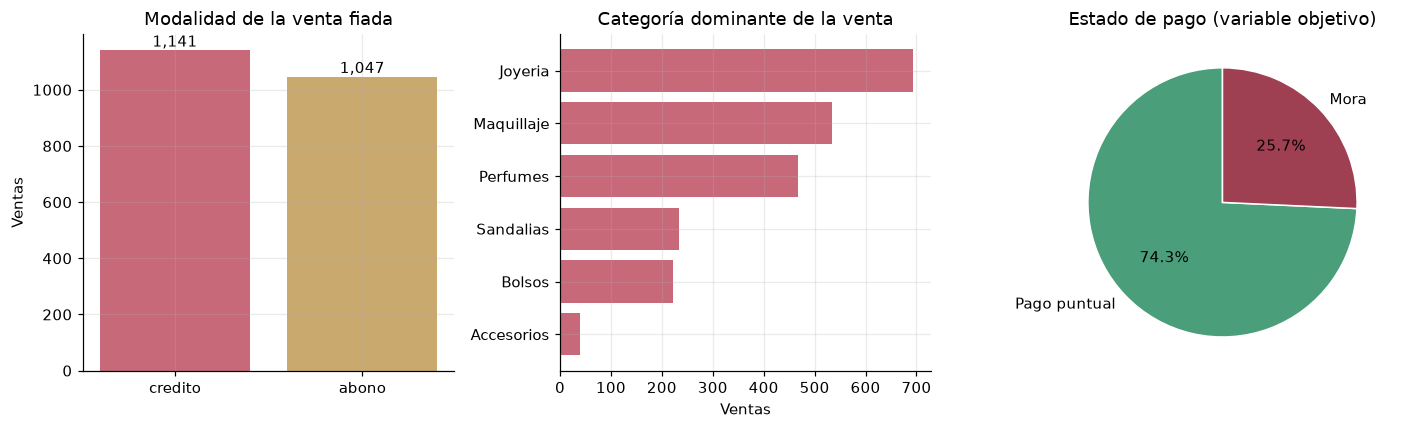

In [7]:
fig, ejes = plt.subplots(1, 3, figsize=(13, 4))

# Tipo de pago
reparto = datos["tipo_pago"].value_counts()
ejes[0].bar(reparto.index, reparto.values, color=[ROSA, ORO])
ejes[0].set_title("Modalidad de la venta fiada")
ejes[0].set_ylabel("Ventas")
for i, v in enumerate(reparto.values):
    ejes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

# Categoria
categorias = datos["categoria_producto"].value_counts()
ejes[1].barh(categorias.index[::-1], categorias.values[::-1], color=ROSA)
ejes[1].set_title("Categoría dominante de la venta")
ejes[1].set_xlabel("Ventas")

# Variable objetivo
objetivo = datos["estado_pago"].value_counts().sort_index()
ejes[2].pie(objetivo.values, labels=["Pago puntual", "Mora"], colors=[VERDE, ROSA_OSCURO],
            autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "white"})
ejes[2].set_title("Estado de pago (variable objetivo)")

plt.tight_layout()
guardar("02_univariado")

**El desbalance de clases es moderado**: alrededor de una de cada cuatro ventas fiadas
termina en mora.

Es una proporción manejable. Con un 2% habría que recurrir a técnicas de remuestreo; con
un 25% basta con ponderar las clases al entrenar y, sobre todo, **no medir el modelo por
su exactitud**. Un modelo que dijera «nadie cae en mora» acertaría el 74% de las veces y
sería completamente inútil: no detectaría ni un solo caso de los que importan.

---
## 3. Análisis bivariado

Qué relación tiene cada variable con la mora. Esto es lo que decide qué entra al modelo.

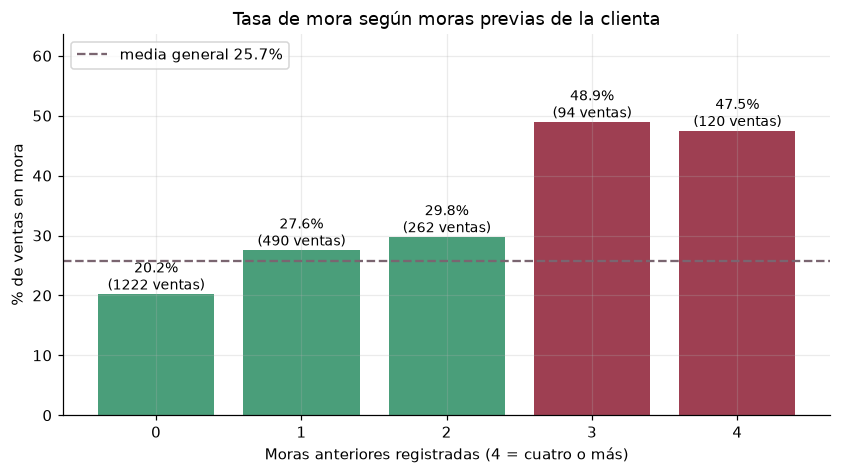

,tasa_mora,ventas
historial_mora,,
0,20.2%,"1,222"
1,27.6%,490
2,29.8%,262
3,48.9%,94
4,47.5%,120


In [8]:
def tasa_de_mora(columna, etiquetas=None, orden=None):
    """Tasa de mora por categoria, con el numero de casos de cada una."""
    tabla = datos.groupby(columna)["estado_pago"].agg(["mean", "size"])
    tabla.columns = ["tasa_mora", "ventas"]
    if orden is not None:
        tabla = tabla.reindex(orden)
    return tabla.sort_values("tasa_mora", ascending=False)


historial = datos["historial_mora"].clip(upper=4)
tabla_historial = datos.groupby(historial)["estado_pago"].agg(["mean", "size"])
tabla_historial.columns = ["tasa_mora", "ventas"]

fig, eje = plt.subplots(figsize=(9, 4.5))
barras = eje.bar(tabla_historial.index.astype(str), tabla_historial["tasa_mora"] * 100,
                 color=[VERDE if t < 0.3 else ORO if t < 0.4 else ROSA_OSCURO
                        for t in tabla_historial["tasa_mora"]])
eje.axhline(datos["estado_pago"].mean() * 100, color=GRIS, linestyle="--",
            label=f"media general {datos['estado_pago'].mean():.1%}")
eje.set_title("Tasa de mora según moras previas de la clienta")
eje.set_xlabel("Moras anteriores registradas (4 = cuatro o más)")
eje.set_ylabel("% de ventas en mora")
eje.legend(loc="upper left")
# Espacio arriba para que las etiquetas de las barras no pisen el titulo.
eje.set_ylim(0, tabla_historial["tasa_mora"].max() * 100 * 1.30)

for barra, (_, fila) in zip(barras, tabla_historial.iterrows()):
    eje.text(barra.get_x() + barra.get_width() / 2, barra.get_height(),
             f"{fila['tasa_mora']:.1%}\n({int(fila['ventas'])} ventas)",
             ha="center", va="bottom", fontsize=9)

guardar("03_mora_por_historial")
tabla_historial.style.format({"tasa_mora": "{:.1%}", "ventas": "{:,.0f}"})

**El hallazgo más fuerte del análisis.** La tasa de mora crece de forma sostenida con el
número de atrasos previos: quien nunca falló ronda el 20%, quien acumula cuatro o más
supera el 45%.

Confirma la hipótesis del avance de proyecto: *el historial de mora es una variable
relevante para el modelo predictivo de riesgo crediticio*.

Conviene subrayar un detalle metodológico: este historial cuenta **solo las moras
anteriores a cada venta**, calculadas cronológicamente. Si incluyera todas las moras de
la clienta —incluida la de la propia venta que se evalúa— el gráfico se vería
espectacular y el modelo sería inservible, porque el día que hay que decidir si fiar ese
futuro todavía no ha ocurrido.

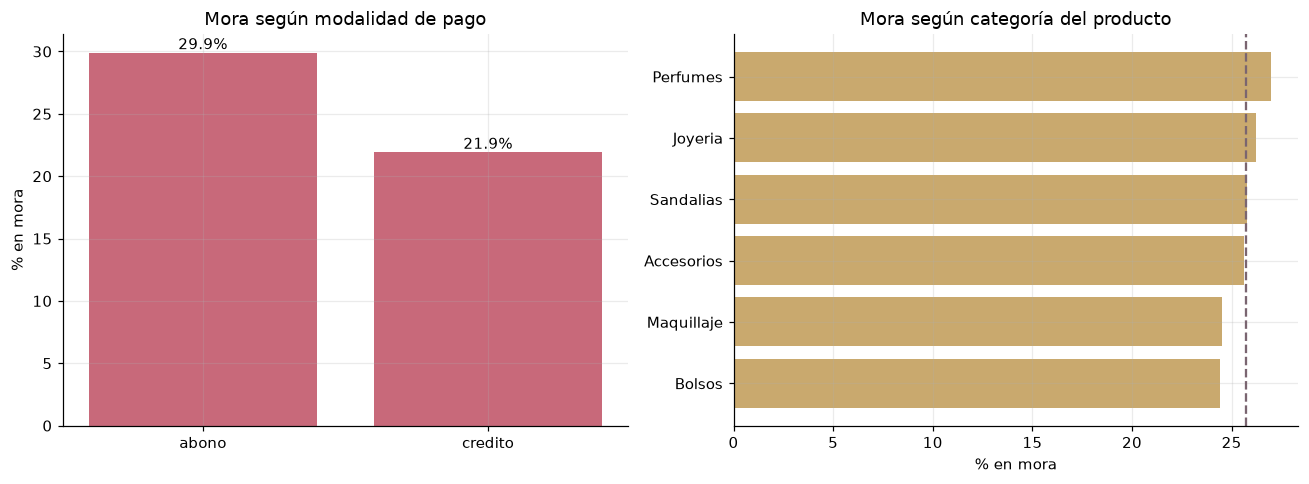

           tasa_mora  ventas
tipo_pago                   
abono          0.299    1047
credito        0.219    1141


In [9]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

# Por tipo de pago
por_tipo = tasa_de_mora("tipo_pago")
ejes[0].bar(por_tipo.index, por_tipo["tasa_mora"] * 100, color=ROSA)
ejes[0].set_title("Mora según modalidad de pago")
ejes[0].set_ylabel("% en mora")
for i, (_, fila) in enumerate(por_tipo.iterrows()):
    ejes[0].text(i, fila["tasa_mora"] * 100, f"{fila['tasa_mora']:.1%}",
                 ha="center", va="bottom")

# Por categoria
por_categoria = tasa_de_mora("categoria_producto")
ejes[1].barh(por_categoria.index[::-1], por_categoria["tasa_mora"][::-1] * 100, color=ORO)
ejes[1].axvline(datos["estado_pago"].mean() * 100, color=GRIS, linestyle="--")
ejes[1].set_title("Mora según categoría del producto")
ejes[1].set_xlabel("% en mora")

plt.tight_layout()
guardar("04_mora_por_tipo_y_categoria")

print(por_tipo.to_string(float_format=lambda x: f"{x:,.3f}"))

Rango de cada tramo (% del total entregado como abono inicial):
                   min   max
Abono alto        57.0  90.0
Abono bajo         8.5  31.0
Abono medio-alto  46.6  57.0
Abono medio-bajo  31.1  46.6


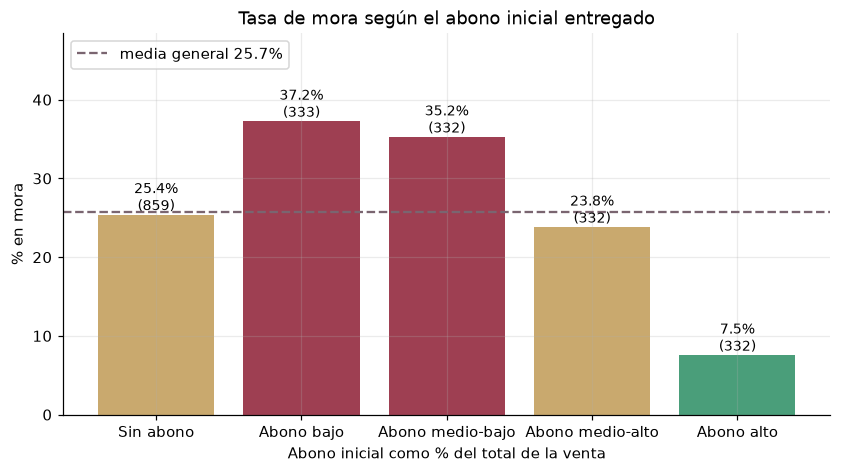

,tasa_mora,ventas
Sin abono,25.4%,859
Abono bajo,37.2%,333
Abono medio-bajo,35.2%,332
Abono medio-alto,23.8%,332
Abono alto,7.5%,332


In [10]:
# El abono inicial, agrupado en tramos: es lo mas accionable de todo el analisis,
# porque la dueña SI puede decidir cuanto pedir antes de entregar la mercaderia.
#
# Los tramos se definen por CUARTILES de las ventas que si llevaron abono, no con
# cortes redondos elegidos a mano. Con cortes fijos (1-15%, 15-30%...) un tramo
# quedaba con nueve ventas y una tasa del 100%: un numero que parece un hallazgo
# rotundo y es ruido de muestra pequeña. Los cuartiles garantizan grupos de
# tamaño comparable, y por tanto comparables entre si.
con_abono = datos["porcentaje_abono_inicial"] > 0

tramos = pd.Series("Sin abono", index=datos.index, dtype="object")
tramos[con_abono] = pd.qcut(
    datos.loc[con_abono, "porcentaje_abono_inicial"], q=4,
    labels=["Abono bajo", "Abono medio-bajo", "Abono medio-alto", "Abono alto"],
).astype(str)

orden = ["Sin abono", "Abono bajo", "Abono medio-bajo", "Abono medio-alto", "Abono alto"]
por_abono = datos.groupby(tramos, observed=True)["estado_pago"].agg(["mean", "size"])
por_abono.columns = ["tasa_mora", "ventas"]
por_abono = por_abono.reindex(orden)

# Rango real de cada tramo, para que las etiquetas signifiquen algo.
rangos = datos[con_abono].groupby(tramos[con_abono], observed=True)["porcentaje_abono_inicial"].agg(["min", "max"])
print("Rango de cada tramo (% del total entregado como abono inicial):")
print(rangos.round(1).to_string())

fig, eje = plt.subplots(figsize=(9, 4.5))
barras = eje.bar(por_abono.index.astype(str), por_abono["tasa_mora"] * 100,
                 color=[ROSA_OSCURO if t > 0.3 else ORO if t > 0.22 else VERDE
                        for t in por_abono["tasa_mora"]])
eje.axhline(datos["estado_pago"].mean() * 100, color=GRIS, linestyle="--",
            label=f"media general {datos['estado_pago'].mean():.1%}")
eje.set_title("Tasa de mora según el abono inicial entregado")
eje.set_xlabel("Abono inicial como % del total de la venta")
eje.set_ylabel("% en mora")
eje.legend(loc="upper left")
eje.set_ylim(0, por_abono["tasa_mora"].max() * 100 * 1.30)

for barra, (_, fila) in zip(barras, por_abono.iterrows()):
    eje.text(barra.get_x() + barra.get_width() / 2, barra.get_height(),
             f"{fila['tasa_mora']:.1%}\n({int(fila['ventas'])})",
             ha="center", va="bottom", fontsize=9)

guardar("05_mora_por_abono_inicial")
por_abono.style.format({"tasa_mora": "{:.1%}", "ventas": "{:,.0f}"})

**Entre las ventas que llevaron abono inicial, la relación es nítida y monótona**: cuanto
más entrega la clienta por adelantado, menos mora. Del 37% en el cuartil más bajo al 7,5%
en el más alto.

Ahora bien, hay un detalle que conviene mirar con cuidado antes de sacar conclusiones.
El grupo **«Sin abono» tiene menos mora (25,4%) que el de «Abono bajo» (37,2%)**, lo cual
parece contradecir todo lo anterior.

No es una contradicción: es un **factor de confusión**. Las ventas sin abono inicial son
las de modalidad *crédito puro*, y esas se conceden precisamente a las clientas en las que
la dueña ya confía. El grupo no es comparable con los demás porque no se formó al azar —
se formó por una decisión previa que ya incorporaba información sobre el riesgo.

Es un ejemplo de por qué **una tabla cruzada no demuestra causalidad**. Para afirmar «pedir
más abono inicial reduce la mora» habría que comparar clientas equivalentes a las que se
les pidió distinto anticipo, y eso este conjunto de datos no lo permite. Lo que sí se puede
afirmar, y es útil, es que *entre quienes reciben la misma modalidad*, el anticipo separa
bien el riesgo.

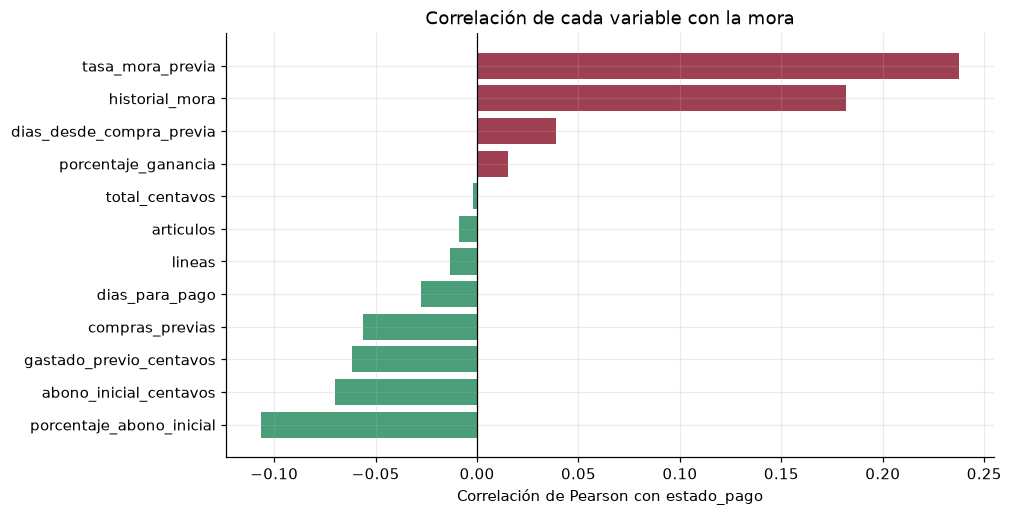

Las mas relacionadas con la mora:
tasa_mora_previa           0.237
historial_mora             0.182
porcentaje_abono_inicial   0.106
abono_inicial_centavos     0.070
gastado_previo_centavos    0.062
compras_previas            0.056


In [11]:
# Correlaciones entre las variables numericas y el objetivo.
numericas = [
    "total_centavos", "abono_inicial_centavos", "porcentaje_abono_inicial",
    "porcentaje_ganancia", "articulos", "lineas", "dias_para_pago",
    "historial_mora", "compras_previas", "tasa_mora_previa",
    "gastado_previo_centavos", "dias_desde_compra_previa", "estado_pago",
]

correlaciones = datos[numericas].corr()["estado_pago"].drop("estado_pago").sort_values()

fig, eje = plt.subplots(figsize=(9, 5))
colores = [ROSA_OSCURO if c > 0 else VERDE for c in correlaciones]
eje.barh(correlaciones.index, correlaciones.values, color=colores)
eje.axvline(0, color="black", linewidth=0.8)
eje.set_title("Correlación de cada variable con la mora")
eje.set_xlabel("Correlación de Pearson con estado_pago")

guardar("06_correlaciones")

print("Las mas relacionadas con la mora:")
print(correlaciones.abs().sort_values(ascending=False).head(6).to_string(
    float_format=lambda x: f"{x:.3f}"))

**Ninguna correlación es alta, y eso es exactamente lo que debería pasar.**

Si una sola variable correlacionara 0.9 con la mora, lo primero que habría que hacer es
sospechar de una fuga de información — alguna columna que contiene, disfrazada, la
respuesta. Aquí las relaciones son moderadas y repartidas, que es como se comporta un
problema real: **el riesgo no está en una variable, está en la combinación**.

Es también la razón para probar un modelo no lineal como Random Forest y no quedarse solo
con la regresión logística: puede capturar interacciones que ninguna correlación simple
muestra.

---
## 4. Análisis temporal

Cómo se comportan las ventas y la mora a lo largo del tiempo. Alimenta el modelo de
proyección del cuaderno 3.

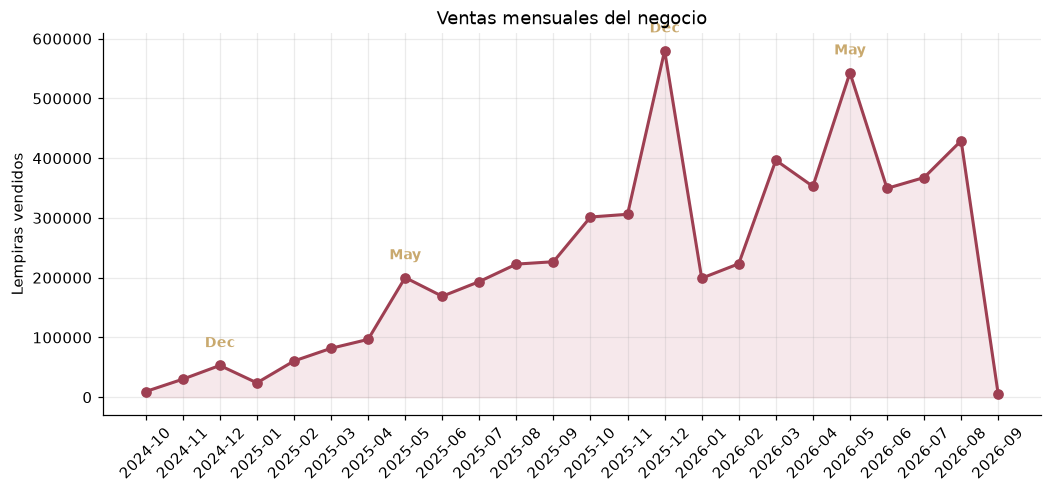

,vendido,ventas
mes,,
2026-02,"L 223,360",136
2026-03,"L 396,580",267
2026-04,"L 352,850",250
2026-05,"L 543,020",389
2026-06,"L 349,520",233
2026-07,"L 367,640",236
2026-08,"L 429,260",292
2026-09,"L 4,900",4


In [12]:
# Todas las ventas del negocio, no solo las fiadas: para proyectar ingresos hacen
# falta tambien las de contado. Se leen directamente de la base.
from etl.extraer import extraer
from etl.transformar import totales_por_venta

tablas = extraer()
todas = tablas["ventas"].merge(
    totales_por_venta(tablas["venta_items"]), left_on="id", right_index=True, how="inner"
)
todas["mes"] = todas["fecha"].dt.to_period("M")

mensual = todas.groupby("mes").agg(
    vendido=("total_centavos", "sum"),
    ventas=("id", "size"),
)
mensual["vendido"] = lempiras(mensual["vendido"])

fig, eje = plt.subplots(figsize=(11, 4.5))
eje.plot(mensual.index.astype(str), mensual["vendido"], marker="o", color=ROSA_OSCURO, linewidth=2)
eje.fill_between(range(len(mensual)), mensual["vendido"], alpha=0.15, color=ROSA)
eje.set_title("Ventas mensuales del negocio")
eje.set_ylabel("Lempiras vendidos")
eje.tick_params(axis="x", rotation=45)

# Se señalan los picos: diciembre y mayo, navidad y dia de la madre.
for i, (periodo, fila) in enumerate(mensual.iterrows()):
    if periodo.month in (5, 12):
        eje.annotate(f"{periodo.strftime('%b')}", (i, fila["vendido"]),
                     textcoords="offset points", xytext=(0, 12),
                     ha="center", fontsize=9, color=ORO, weight="bold")

guardar("07_ventas_mensuales")
mensual.tail(8).style.format({"vendido": "L {:,.0f}", "ventas": "{:,.0f}"})

Se aprecia **estacionalidad**: mayo y diciembre destacan sobre el resto, coincidiendo con
el día de la madre y la navidad. Enero y febrero caen, que es lo esperable después del
gasto navideño.

Esa estructura es lo que hace viable un modelo de series de tiempo con componente
estacional (cuaderno 3), y tiene consecuencia directa en el negocio: **el inventario para
mayo y diciembre hay que comprarlo con antelación**.

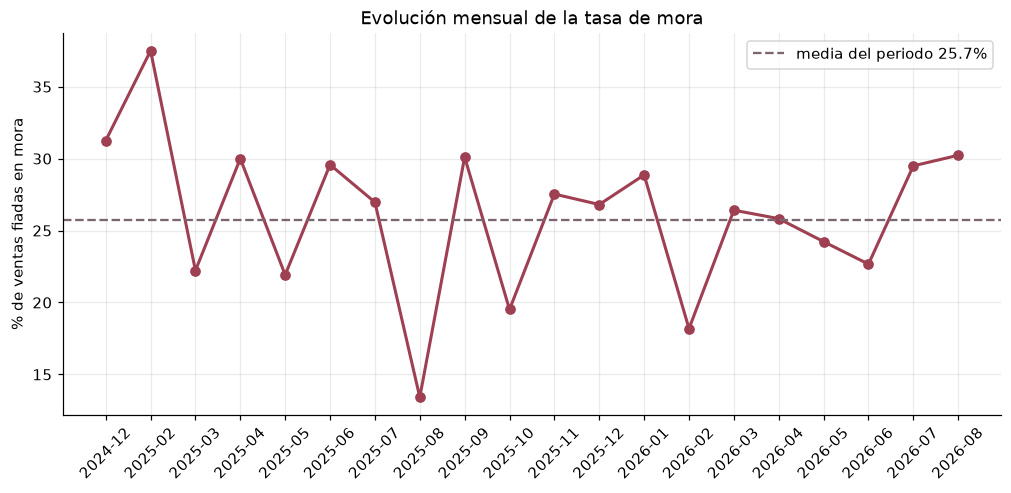

In [13]:
por_mes = datos.groupby(datos["fecha"].dt.to_period("M"))["estado_pago"].agg(["mean", "size"])
por_mes.columns = ["tasa_mora", "ventas"]
por_mes = por_mes[por_mes["ventas"] >= 10]   # meses con muy pocas ventas no dicen nada

fig, eje = plt.subplots(figsize=(11, 4.5))
eje.plot(por_mes.index.astype(str), por_mes["tasa_mora"] * 100,
         marker="o", color=ROSA_OSCURO, linewidth=2)
eje.axhline(datos["estado_pago"].mean() * 100, color=GRIS, linestyle="--",
            label=f"media del periodo {datos['estado_pago'].mean():.1%}")
eje.set_title("Evolución mensual de la tasa de mora")
eje.set_ylabel("% de ventas fiadas en mora")
eje.tick_params(axis="x", rotation=45)
eje.legend()

guardar("08_mora_mensual")

---
## 5. Conclusiones del análisis exploratorio

**Qué predice la mora**

1. **El historial de la clienta es la señal más fuerte.** De ~20% de mora sin atrasos
   previos a más del 45% con cuatro o más. Es la variable que el modelo debe aprovechar.
2. **El abono inicial separa bien el riesgo, y es accionable.** Entre las ventas con
   anticipo, la mora cae del 37% al 7,5% del cuartil más bajo al más alto. A diferencia
   del historial, esto la dueña **sí puede decidirlo** antes de entregar la mercadería.
   Con la salvedad ya dicha: el grupo sin abono no es comparable porque se formó por una
   decisión previa que ya incorporaba información sobre el riesgo.
3. **Ninguna variable por sí sola resuelve el problema.** Las correlaciones son moderadas
   y repartidas: el riesgo está en la combinación, no en un único indicador.

**Qué implica para el modelado**

- El desbalance (≈26% de mora) exige **ponderar las clases** y medir con *recall* y
  *F1*, no con exactitud. Un modelo que dijera «nadie cae en mora» acertaría el 74% y no
  serviría para nada.
- Conviene comparar un modelo lineal (regresión logística, interpretable) con uno no
  lineal (Random Forest, capaz de capturar interacciones).
- El monto tiene cola larga; los modelos de árbol no se ven afectados, los lineales sí.

**Limitación que arrastra el conjunto de datos**

Cuando una venta no tuvo recordatorio agendado no existe fecha prometida registrada, y el
ETL asume un plazo de 30 días — más generoso que los 8 o 15 que se pactan de palabra. Esas
ventas aparecen con **menos mora de la real**. No se puede corregir porque el dato no
existe, pero se declara, y `tuvo_recordatorio` entra como variable para que el modelo
pueda tenerlo en cuenta.

---

**Siguiente cuaderno:** `02_riesgo_de_mora.ipynb` — entrenamiento y evaluación de los
modelos de clasificación.